In [13]:
import pandas as pd
import numpy as np
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge

In [14]:
X,y = make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=13)

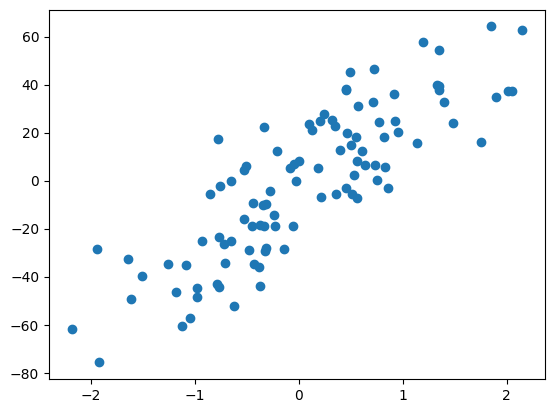

In [15]:
plt.scatter(X,y)
plt.show()

In [16]:
lr = LinearRegression()
lr.fit(X,y)
print(lr.coef_,lr.intercept_)

[27.82809103] -2.29474455867698


In [18]:
rd = Ridge(alpha=10)
rd.fit(X,y)
print(rd.coef_,rd.intercept_)

[24.9546267] -2.1269130035235735


In [20]:
rdd = Ridge(alpha=100)
rdd.fit(X,y)
print(rdd.coef_,rdd.intercept_)

[12.93442104] -1.4248441496033308


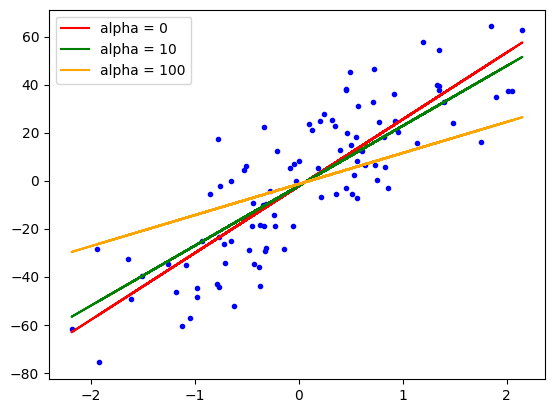

In [24]:
plt.plot(X,y,'b.')
plt.plot(X,lr.predict(X),color='red',label='alpha = 0')
plt.plot(X,rd.predict(X),color='green',label='alpha = 10')
plt.plot(X,rdd.predict(X),color='orange',label='alpha = 100')
plt.legend()
plt.show()

In [26]:
class MyRidgeRegressionTwoD:
  def __init__(self,alpha=0.1):
    self.alpha = alpha
    self.m = None
    self.b = None

  def fit(self,X_train,Y_train):

    num = 0
    den = 0

    for i in range(X_train.shape[0]):
      num = num + (Y_train[i]-Y_train.mean())*(X_train[i]-X_train.mean())
      den = den + (X_train[i]-X_train.mean())*(X_train[i]-X_train.mean())

    self.m = num/(den + self.alpha)
    self.b = Y_train.mean() - self.m*X_train.mean()
    print(self.m,self.b)
  def predict(self,X_test):
    return X_test*self.m + self.b

In [27]:
myrr = MyRidgeRegressionTwoD(alpha=10)
myrr.fit(X,y)

[24.9546267] [-2.126913]


In [29]:
myrrd = MyRidgeRegressionTwoD(alpha=100)
myrrd.fit(X,y)

[12.93442104] [-1.42484415]


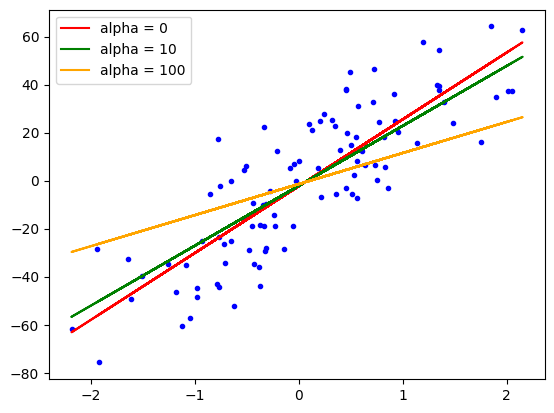

In [30]:
plt.plot(X,y,'b.')
plt.plot(X,lr.predict(X),color='red',label='alpha = 0')
plt.plot(X,myrr.predict(X),color='green',label='alpha = 10')
plt.plot(X,myrrd.predict(X),color='orange',label='alpha = 100')
plt.legend()
plt.show()